In [3]:
import os
import pathlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shutil
import random
import tensorflow as tf
from tensorflow import keras
import tensorflow_hub as hub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D, Activation, GlobalMaxPool2D, BatchNormalization
from tensorflow.keras.optimizers import Adam, Nadam
from tensorflow.keras import Input, Model
from tensorflow.keras.utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import splitfolders

In [4]:
# splits dataset it into three subfolders: train, val (validation), and test.

splitfolders.ratio("Medicinal plant dataset", output="output",
    seed=1337, ratio=(.75, .2, .05), group_prefix=None, move=False)

In [5]:
data_dir = pathlib.Path('output/')
train_dir = 'output/train'
val_dir = 'output/val'
test_dir = 'output/test'

In [6]:
class_name = np.array(sorted([item.name for item in data_dir.glob("*")]))
print(class_name)

['test' 'train' 'val']


In [7]:
for dirpath, dirnames, filenames in os.walk('output'):
  print(f"{len(dirnames)} folder and {len(filenames)} images in {dirpath}")

3 folder and 0 images in output
38 folder and 0 images in output\test
0 folder and 9 images in output\test\Aloevera
0 folder and 8 images in output\test\Amla
0 folder and 8 images in output\test\Amruta_Balli
0 folder and 8 images in output\test\Arali
0 folder and 8 images in output\test\Ashoka
0 folder and 8 images in output\test\Ashwagandha
0 folder and 8 images in output\test\Avacado
0 folder and 8 images in output\test\Bamboo
0 folder and 8 images in output\test\Basale
0 folder and 8 images in output\test\Betel
0 folder and 8 images in output\test\Betel_Nut
0 folder and 8 images in output\test\Brahmi
0 folder and 8 images in output\test\Castor
0 folder and 8 images in output\test\Curry_Leaf
0 folder and 8 images in output\test\Doddapatre
0 folder and 8 images in output\test\Ekka
0 folder and 6 images in output\test\Ganike
0 folder and 8 images in output\test\Gauva
0 folder and 8 images in output\test\Henna
0 folder and 9 images in output\test\Hibiscus
0 folder and 8 images in output

In [8]:
def view_random_image(target_dir, target_class):
    target_folder = target_dir + target_class
    random_image = random.sample(os.listdir(target_folder), 1)
    img = mpimg.imread(target_folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")
    
    print(f"Image Shape : {img.shape}")
    plt.show()

Image Shape : (450, 600, 3)


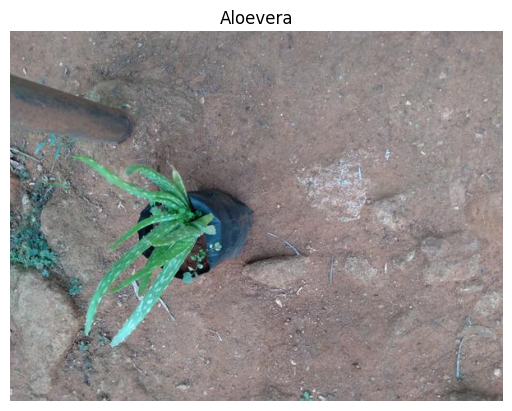

In [9]:
for i in range(1,2):
    img_n = view_random_image(target_dir='output/train/', target_class='Aloevera')

In [12]:
# Sets the global random seed.
tf.random.set_seed(46)

# preprocess data
train_datagen = ImageDataGenerator(rescale=1/255.0,
                                   rotation_range=0.2,
                                   zoom_range=0.2,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   vertical_flip=True,
                                   horizontal_flip=True)
valid_datagen = ImageDataGenerator(rescale=1/255.0)
test_datagen = ImageDataGenerator(rescale=1/255.0)

In [13]:
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=64,
                                               target_size=(224, 224),
                                               class_mode='categorical',
                                               shuffle=True,
                                               seed=46)

valid_data = valid_datagen.flow_from_directory(val_dir,
                                               batch_size=64,
                                               target_size=(224, 224),
                                               class_mode='categorical',
                                               shuffle=False,
                                               seed=46)

test_data = test_datagen.flow_from_directory(test_dir,
                                               batch_size=64,
                                               target_size=(224, 224),
                                               class_mode='categorical',
                                               shuffle=False,
                                               seed=46)

Found 4223 images belonging to 38 classes.
Found 1122 images belonging to 38 classes.
Found 308 images belonging to 38 classes.


In [14]:
train_data.class_indices

{'Aloevera': 0,
 'Amla': 1,
 'Amruta_Balli': 2,
 'Arali': 3,
 'Ashoka': 4,
 'Ashwagandha': 5,
 'Avacado': 6,
 'Bamboo': 7,
 'Basale': 8,
 'Betel': 9,
 'Betel_Nut': 10,
 'Brahmi': 11,
 'Castor': 12,
 'Curry_Leaf': 13,
 'Doddapatre': 14,
 'Ekka': 15,
 'Ganike': 16,
 'Gauva': 17,
 'Henna': 18,
 'Hibiscus': 19,
 'Honge': 20,
 'Insulin': 21,
 'Jasmine': 22,
 'Lemon': 23,
 'Lemon_grass': 24,
 'Mango': 25,
 'Mint': 26,
 'Nagadali': 27,
 'Neem': 28,
 'Nithyapushpa': 29,
 'Nooni': 30,
 'Pappaya': 31,
 'Pepper': 32,
 'Pomegranate': 33,
 'Raktachandini': 34,
 'Rose': 35,
 'Sapota': 36,
 'Wood_sorel': 37}

In [15]:
train_y=train_data.classes
val_y=valid_data.classes
test_y=test_data.classes

In [16]:
print("train_y.shape: ", train_y.shape)
print("val_y.shape: ", val_y.shape)
print("test_y.shape: ", test_y.shape)

train_y.shape:  (4223,)
val_y.shape:  (1122,)
test_y.shape:  (308,)


In [17]:
base_model = tf.keras.applications.DenseNet121(input_shape=(224, 224, 3),
                                                        include_top=False,
                                                        weights='imagenet')
base_model.trainable = False

In [18]:
global_average_layer = GlobalAveragePooling2D()
prediction_layer = Dense(38)
softmax = Activation('softmax')

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = Dropout(0.25)(x)
x = global_average_layer(x)
outputs = prediction_layer(x)
outputs = softmax(outputs)

model = Model(inputs, outputs)

In [19]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        38,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 38)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,076,454 (26.99 MB)

 Trainable params: 38,950 (152.15 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [20]:
plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [21]:
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

# train model
history = model.fit(train_data, epochs=40, validation_data=valid_data)

Epoch 1/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 325s 5s/step - accuracy: 0.2247 - loss: 3.0794 - val_accuracy: 0.4893 - val_loss: 2.1716
Epoch 2/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 280s 4s/step - accuracy: 0.5567 - loss: 1.9836 - val_accuracy: 0.6676 - val_loss: 1.4753
Epoch 3/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.6919 - loss: 1.4630 - val_accuracy: 0.7282 - val_loss: 1.1738
Epoch 4/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.7495 - loss: 1.1865 - val_accuracy: 0.7861 - val_loss: 0.9171
Epoch 5/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - accuracy: 0.7878 - loss: 1.0069 - val_accuracy: 0.8048 - val_loss: 0.8341
Epoch 6/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accuracy: 0.8125 - loss: 0.8868 - val_accuracy: 0.8316 - val_loss: 0.7205
Epoch 7/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.8342 - loss: 0.7898 - val_accuracy: 0.8414 - val_loss: 0.6471
Epoch 8/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accuracy: 0.8487 - loss: 0.7209 - val_accuracy: 0.8636 - v

In [22]:
def plot_loss_curves(history):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(loss))

  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title("Loss Curves")
  plt.xlabel("Epochs")
  plt.legend()

  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title("Accuracy Curves")
  plt.xlabel("Epochs")
  plt.legend()

In [23]:
val_pred = model.predict(valid_data)
val_pred = val_pred.argmax(axis=1)
print(classification_report(val_pred, val_y))

18/18 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       1.00      0.97      0.98        30
           2       0.86      0.74      0.79        34
           3       1.00      1.00      1.00        29
           4       1.00      1.00      1.00        29
           5       1.00      0.88      0.94        33
           6       0.97      0.85      0.90        33
           7       1.00      1.00      1.00        29
           8       0.97      1.00      0.98        28
           9       0.97      0.91      0.94        32
          10       0.97      0.93      0.95        30
          11       0.90      0.93      0.91        28
          12       0.91      1.00      0.95        29
          13       1.00      0.97      0.98        30
          14       1.00      0.97      0.98        30
          15       1.00      0.97      0.98        30
          16       1.00      0.88      0.9

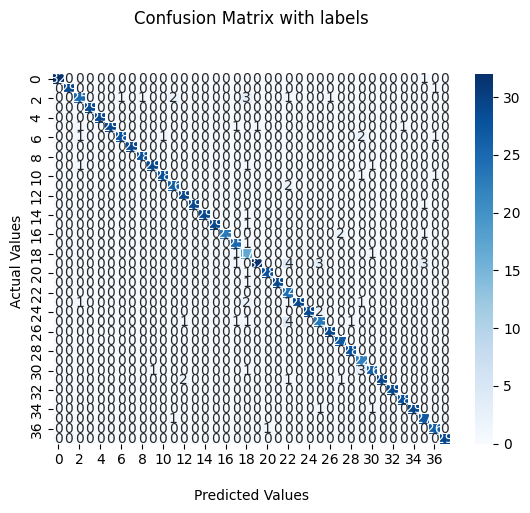

In [24]:
cfm_val = confusion_matrix(val_pred, val_y)
ax = sns.heatmap(cfm_val, annot=True, 
            cmap='Blues')

# Preparation for plotting confusion matrix
ax.set_title('Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

# Display the visualization of the Confusion Matrix.
plt.show()

In [26]:
test_pred = model.predict(test_data)
test_pred = test_pred.argmax(axis=1)
print(classification_report(test_pred, test_y))

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       1.00      1.00      1.00         8
           2       0.50      0.80      0.62         5
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      0.89      0.94         9
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       0.75      0.86      0.80         7
           9       1.00      0.89      0.94         9
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8
          12       0.88      1.00      0.93         7
          13       1.00      1.00      1.00         8
          14       1.00      1.00      1.00         8
          15       1.00      1.00      1.00         8
          16       0.83      0.83      0.83 

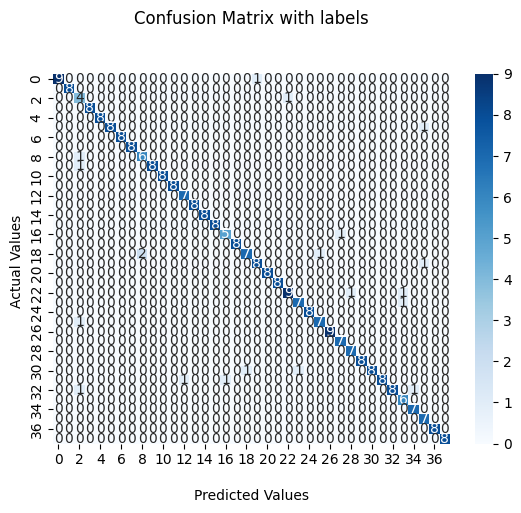

In [27]:
cfm_test = confusion_matrix(test_pred, test_y)
ax = sns.heatmap(cfm_test, annot=True, 
            cmap='Blues')

# Preparation for plotting confusion matrix
ax.set_title('Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

# Display the visualization of the Confusion Matrix.
plt.show()

In [28]:
model.save('my_model.keras')